### From Prompt to Action

传统AI是被动式交互，需要输入提示词完成任务需求。智能体可以进行多轮“思考-行动”循环完成复杂的任务  
本质：将大语言模型从文本生成变为具备任务执行能力的智能系统

#### 一、组成 
1. 模型：由LLM充当，负责推理，规划和决策。不仅仅是预测下一个字，而是通过思维链等技术理解复杂指令  
2. 手脚（tools）：智能体通过函数调用或扩展，与外部世界交互
3. 记忆：
   - 短期记忆：LLM的上下文窗口，记录当前对话的轮次
   - 长期记忆：通常利用向量数据库存储历史经验或外部知识库，通过RAG获取信息  
  4. 编排层：管理智能体的内部推理流程、目标设定和状态流程，确保任务被逻辑执行

#### 二、执行任务的过程：ReAct循环机制
智能体执行任务的核心逻辑通常为先思考，再行动，最后观察结果。  

执行逻辑流：
- Thought (思考): 智能体分析当前任务，决定下一步该做什么
- Action (行动): 从工具箱中选择一个工具并调用
- Observation (观察): 接收工具返回的结果（如 API 的 JSON 数据或代码运行错误）
- Loop (循环): 将观察到的新信息放回上下文，进行下一轮 Thought，直到得出最终答案

#### 三、工程落地要点
1. 模型选择
  - 选择推理能力强、工具调用可靠的模型
  - 采用模型路由：
    - 高复杂度：高性能（Gemini 1.5 pro）
    - 简单高频任务：轻量模型(Gemini 1.5 Flash)
2. 工具调用的可靠性
 - 检索：RAG+向量数据库；或NL2SQL查询结构化数据
 - 操作层：通过API封装工具功能；部分智能体可以在沙箱里执行Python
3. 记忆系统：
  - 短期记忆：任务执行中产生的上下文
  - 长期记忆：跨任务持久化，如用户偏好，历史交互；常用RAG+向量数据库实现
4. 测试与调式：
  - 评估：LLM评估结果准确性、合规性
  - 调式：OpenTelemetry,对每一步思考、工具参数、返回值进行追踪
  - 持续优化：失败案例加入测试集
5. 安全与规模化：
  - 多层安全体系：规则护栏+AI驱动
  - 身份管理：智能体具备独立数字身份，实现最小权限
  - 规模化治理：通过集中控制平面统一管理

## 环境配置
参考课程是在Kaggle上运行的。为了本地执行任务，该教程并未使用Kaggle  
1. 首先需要GEMINI的API密钥 https://aistudio.google.com/app/api-keys   
2. 在终端中全局设置Gemini的API密钥，建议配置虚拟环境 https://blog.csdn.net/weixin_54383080/article/details/138613865?ops_request_misc=&request_id=&biz_id=102&utm_term=vscode%E9%85%8D%E7%BD%AE%E8%99%9A%E6%8B%9F%E7%8E%AF%E5%A2%83&utm_medium=distribute.pc_search_result.none-task-blog-2~all~sobaiduweb~default-2-138613865.142^v102^pc_search_result_base8&spm=1018.2226.3001.4187  

- 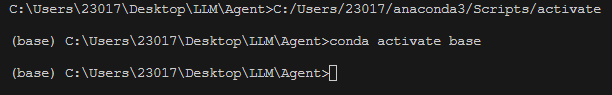  

- 目前python环境为base，需要切换环境为虚拟环境  

- 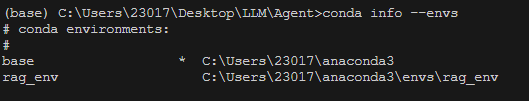    

- conda activate 虚拟环境名称  

3. 切换成功后，全局配置GEMINI的API密钥：setx GOOGLE_API_KEY "你的真实APIKey"  
下载：pip install python-dotenv


In [1]:
import os

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY not found in environment variables")

print("API Key loaded successfully.")

API Key loaded successfully.


In [2]:
from google.adk.agents import Agent
from google.adk.models.google_llm import Gemini
from google.adk.runners import InMemoryRunner
from google.adk.tools import google_search
from google.genai import types

print("✅ ADK components imported successfully.")

✅ ADK components imported successfully.


In [3]:
from IPython.display import display, HTML

def get_adk_proxy_url():
    ADK_PORT = 8000
    url = f"http://localhost:{ADK_PORT}"

    styled_html = f"""
    <div style="padding: 15px; border: 2px solid #28a745; border-radius: 8px; background-color: #f0fff4; margin: 20px 0;">
        <div style="font-family: sans-serif; margin-bottom: 12px; color: #333; font-size: 1.1em;">
            <strong>Local ADK Web UI</strong>
        </div>
        <div style="font-family: sans-serif; margin-bottom: 15px; color: #333; line-height: 1.5;">
            Make sure the ADK web server is running on port {ADK_PORT}.
        </div>
        <a href='{url}' target='_blank' style="
            display: inline-block; background-color: #1a73e8; color: white; padding: 10px 20px;
            text-decoration: none; border-radius: 25px; font-family: sans-serif; font-weight: 500;">
            Open ADK Web UI ↗
        </a>
    </div>
    """

    display(HTML(styled_html))
    return url


print("✅ Local helper function defined.")

✅ Local helper function defined.


In [4]:
retry_config=types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1, # Initial delay before first retry (in seconds)
    http_status_codes=[429, 500, 503, 504] # Retry on these HTTP errors
)

In [5]:
root_agent = Agent(
    name="helpful_assistant",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    description="A simple agent that can answer general questions.",
    instruction="You are a helpful assistant. Use Google Search for current info or if unsure.",
    tools=[google_search],
)

print("✅ Root Agent defined.")

✅ Root Agent defined.


In [6]:
runner = InMemoryRunner(agent=root_agent)

print("✅ Runner created.")

✅ Runner created.


In [7]:
response = await runner.run_debug(
    "What is Agent Development Kit from Google? What languages is the SDK available in?"
)


 ### Created new session: debug_session_id

User > What is Agent Development Kit from Google? What languages is the SDK available in?
helpful_assistant > The Google Agent Development Kit (ADK) is a flexible and modular open-source framework designed to simplify the development and deployment of AI agents and multi-agent systems. It aims to make agent development more akin to traditional software development, enabling developers to create, deploy, and orchestrate agentic architectures for tasks ranging from simple functions to complex workflows. ADK provides precise control over agent behavior and orchestration, and supports a rich tool ecosystem, allowing agents to interact with external capabilities. While optimized for Google's Gemini models and ecosystem, ADK is model-agnostic and compatible with other frameworks.

The SDK is currently available in the following programming languages:
*   Python
*   Java
*   Go


In [8]:
response = await runner.run_debug("What's the weather in London?")


 ### Continue session: debug_session_id

User > What's the weather in London?
helpful_assistant > The weather in London is currently cloudy with a temperature of 49°F (9°C). There is a 93% humidity and it feels like 45°F (7°C). The chance of rain today is around 9%.

Looking ahead, the forecast for the next few days includes a mix of cloudy skies, light rain, and some sunshine. Temperatures are expected to range between the low 40s°F and mid-50s°F.


In [9]:
!adk create sample_agent --model gemini-2.5-flash-lite --api_key $GOOGLE_API_KEY


Agent created in c:\Users\23017\Desktop\LLM\Agent\sample_agent:
- .env
- __init__.py
- agent.py



In [10]:
url_prefix = get_adk_proxy_url()

In [11]:
!adk web --url_prefix {url_prefix}


+-----------------------------------------------------------------------------+
| ADK Web Server started                                                      |
|                                                                             |
| For local testing, access at http://127.0.0.1:8000.                         |
+-----------------------------------------------------------------------------+


+-----------------------------------------------------------------------------+
| ADK Web Server shutting down...                                             |
+-----------------------------------------------------------------------------+



2026-02-26 14:46:09,656 - INFO - service_factory.py:266 - Using in-memory memory service
2026-02-26 14:46:09,657 - INFO - local_storage.py:84 - Using per-agent session storage rooted at C:\Users\23017\Desktop\LLM\Agent
2026-02-26 14:46:09,658 - INFO - local_storage.py:110 - Using file artifact service at C:\Users\23017\Desktop\LLM\Agent\.adk\artifacts
c:\Users\23017\anaconda3\envs\rag_env\Lib\site-packages\google\adk\cli\fast_api.py:192: UserWarning: [EXPERIMENTAL] InMemoryCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  credential_service = InMemoryCredentialService()
c:\Users\23017\anaconda3\envs\rag_env\Lib\site-packages\google\adk\auth\credential_service\in_memory_credential_service.py:33: UserWarning: [EXPERIMENTAL] BaseCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any 